# Enviornment Variables


Configurng data directory


In [1]:
data_dir = "/Volumes/Samsung_PSSD_T7_Shield/Datasets/EEG Sleep/sleep-cassette"


# File Handling


Finding all file paths and storing them in a list


In [2]:
from glob import glob
import os

psg_files = sorted(glob(os.path.join(data_dir, "*PSG.edf")))

hypnogram_files = sorted(glob(os.path.join(data_dir, "*Hypnogram.edf")))

# Loading Data


Using mne library to load "EDF-European Data Format" Data. This is a format developed in 1992 to store data such as EEG, ECG,EMF.

The mne library handles this for us.


In [9]:
import mne


raw_data = mne.io.read_raw_edf(psg_files[0], preload=True, verbose=False)
raw_data

/var/folders/jt/46g4wcz94mb72f5z3kq461s00000gn/T/ipykernel_33431/4130546437.py:4: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw_data = mne.io.read_raw_edf(psg_files[0],preload = True,verbose=False)
/var/folders/jt/46g4wcz94mb72f5z3kq461s00000gn/T/ipykernel_33431/4130546437.py:4: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw_data = mne.io.read_raw_edf(psg_files[0],preload = True,verbose=False)
/var/folders/jt/46g4wcz94mb72f5z3kq461s00000gn/T/ipykernel_33431/4130546437.py:4: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw_data = mne.io.read_raw_edf(psg_files[0],preload = True,verbose=False)


<RawEDF | SC4001E0-PSG.edf, 7 x 7950000 (79500.0 s), ~424.6 MiB, data loaded>

In [36]:
raw_data.info["sfreq"]

100.0

This data contains 7 channels

1.  EEG Fpz-Cz
1.  EEG Pz-Oz
1.  EOG horizontal
1.  Resp oro-nasal
1.  EMG submental,
1.  Temp rectal,
1.  Event marker

We will only be using the EEG signals of Fpz-Cz and Pz-Oz these are 4 electrodes and we meassure the differnece between 2 to get a reading.

The sample rate is 100Hz, this means a 100 measurements are detected each second.

so to get a reading of 20 seconds we would have to see 20\*100 = 2,000 measurements


# Ploting


In [7]:
eeg_data = raw_data.get_data()
eeg_data

eeg_data_channel_1 = eeg_data[0]

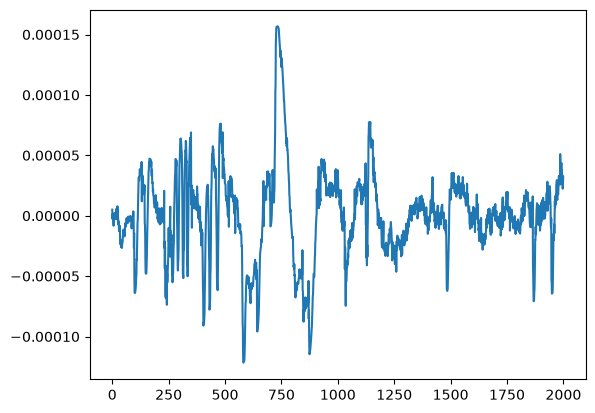

In [8]:
from matplotlib import pyplot as plt


plt.plot(eeg_data_channel_1[:2000])

This is a plot of 20 seconds of EEG reading


Plotting all channels present in the data


In [12]:
eeg_data.shape

(7, 7950000)

In [20]:
channel_names = raw_data.ch_names

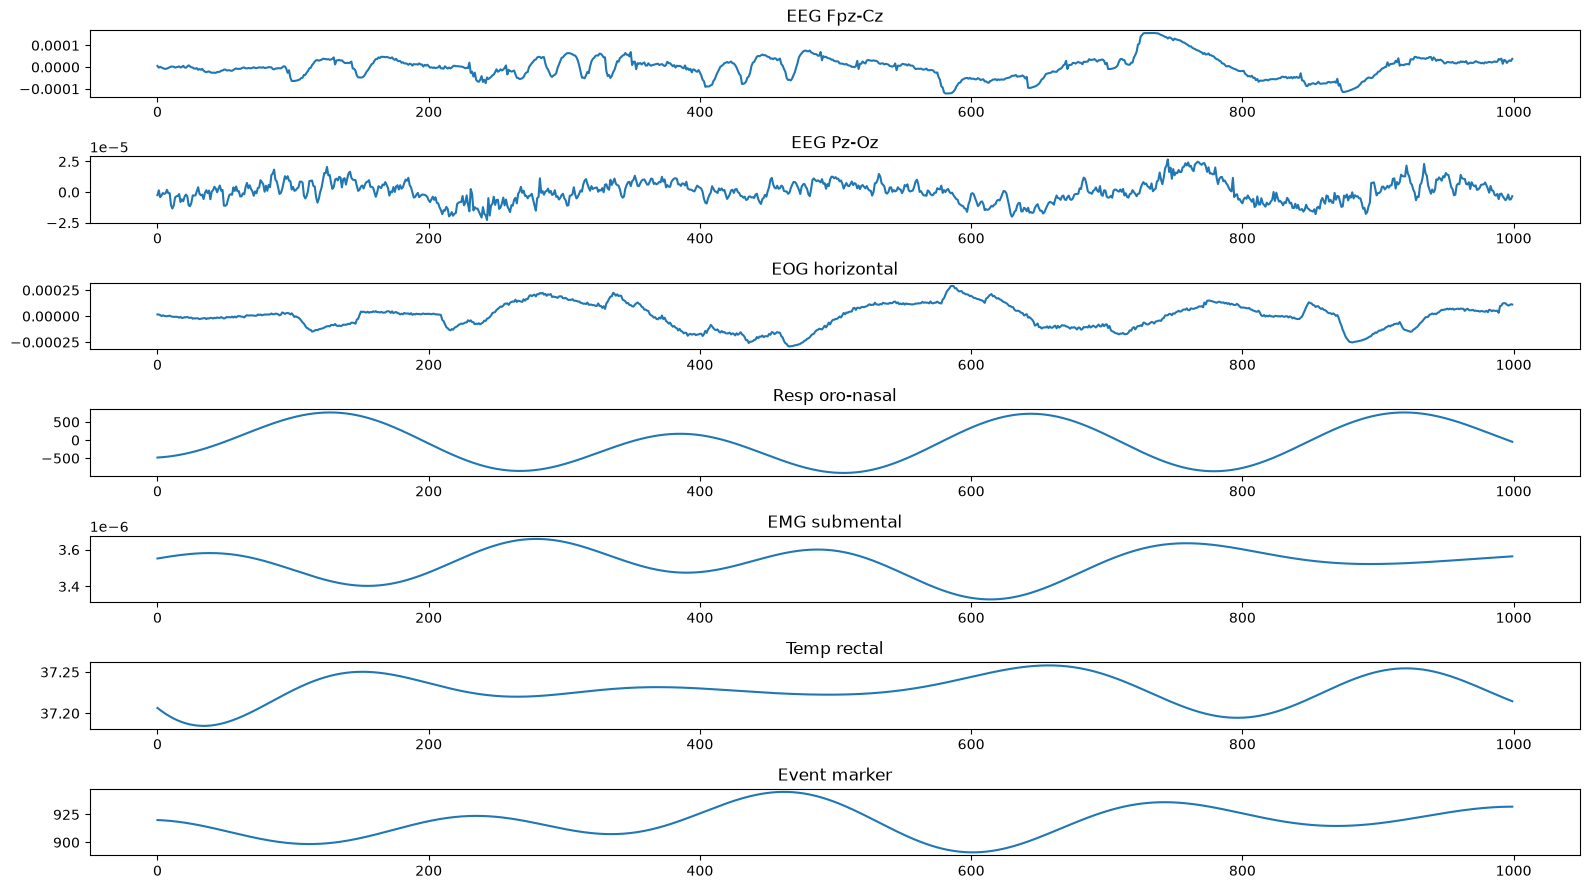

In [25]:
fig, axs = plt.subplots(nrows=eeg_data.shape[0], ncols=1, figsize=(16, 9))

for i, axs in enumerate(axs):
    axs.plot(eeg_data[i][:1000])
    axs.set_title(channel_names[i])

plt.tight_layout()

These are all the channels present in the dataset


# Sleep Stages


In [32]:
annotations = mne.read_annotations(hypnogram_files[0])
annotations.description


array(['Sleep stage W', 'Sleep stage 1', 'Sleep stage 2', 'Sleep stage 3',
       'Sleep stage 2', 'Sleep stage 3', 'Sleep stage 4', 'Sleep stage 3',
       'Sleep stage 4', 'Sleep stage 3', 'Sleep stage 4', 'Sleep stage 3',
       'Sleep stage 4', 'Sleep stage W', 'Sleep stage 3', 'Sleep stage 2',
       'Sleep stage 3', 'Sleep stage 4', 'Sleep stage 3', 'Sleep stage 4',
       'Sleep stage 2', 'Sleep stage 3', 'Sleep stage 2', 'Sleep stage 3',
       'Sleep stage 1', 'Sleep stage 2', 'Sleep stage 3', 'Sleep stage 2',
       'Sleep stage 3', 'Sleep stage 2', 'Sleep stage 3', 'Sleep stage 4',
       'Sleep stage 3', 'Sleep stage 2', 'Sleep stage 3', 'Sleep stage 4',
       'Sleep stage 3', 'Sleep stage 4', 'Sleep stage 1', 'Sleep stage 3',
       'Sleep stage 2', 'Sleep stage 3', 'Sleep stage 2', 'Sleep stage 3',
       'Sleep stage R', 'Sleep stage 1', 'Sleep stage 2', 'Sleep stage 3',
       'Sleep stage 1', 'Sleep stage 2', 'Sleep stage 1', 'Sleep stage 2',
       'Sleep stage 3', '

For subject we can list all the sleep stages using .discription function

We have the following sleep stages in out dataset

1. Sleep Stage W = Waking
1. Sleep Stage 1 = Light Sleep (Low Amplitude,High Frequency)
1. Sleep Stage 2 = Light Sleep (Sleep Splindles, K-Complex)
1. Sleep Stage 3 = Deep Sleep (Slow Waves,Delta Waves(High Amplitude,Low Frequency 20%))
1. Sleep Stage R = Rapid Eye Movement (REM Sleep)

There is also Sleep Stage ? we will remove these values


In [ ]:
annotations.onset

array([    0., 30630., 30750., 31140., 31170., 31200., 31350., 31380.,
       31440., 31500., 31530., 31650., 31680., 31800., 31830., 31890.,
       31950., 32070., 32100., 32130., 32250., 32460., 32490., 32550.,
       32670., 32700., 32850., 32910., 32940., 32970., 33000., 33120.,
       33270., 33300., 33330., 33390., 33420., 33510., 35400., 35430.,
       35640., 35700., 35790., 35940., 35970., 36840., 37020., 37260.,
       37290., 37410., 37500., 37530., 38460., 38490., 38520., 38580.,
       38610., 38640., 38670., 38700., 38730., 38760., 38910., 38970.,
       39060., 39120., 39150., 39180., 39240., 39300., 39480., 39540.,
       39570., 39600., 39870., 39900., 39960., 39990., 40200., 40230.,
       40290., 40320., 40500., 41370., 41400., 41460., 41490., 41610.,
       42480., 42510., 42540., 42570., 42870., 42900., 43290., 43320.,
       43350., 43380., 43410., 43590., 43680., 43710., 43920., 43980.,
       44010., 44040., 44220., 44280., 44340., 44400., 44520., 44640.,
      

This annotation.onset tells use the duration and onset of sleep stages

from 30630 to 30750 the subject was in Sleep Stage 1 ( 2 minutes)

from 30750 to 31140 the subject was in Sleep Stage 2 ( 6.5 minutes )


<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

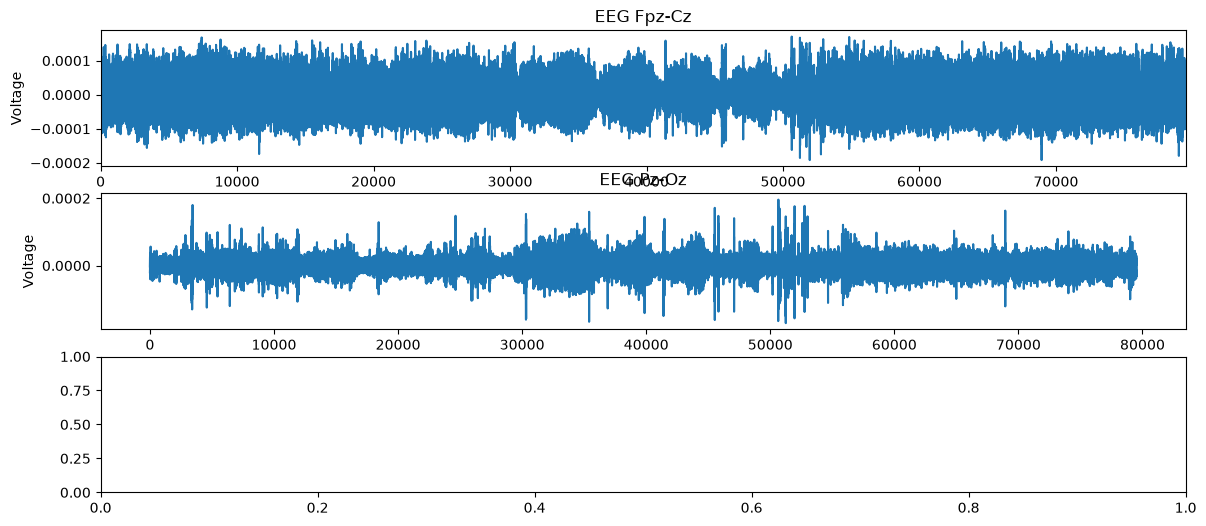

In [ ]:
import numpy as np

fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(14, 6))

seconds = np.arange(eeg_data.shape[1]) / raw_data.info["sfreq"]
seconds

axs[0].plot(seconds, eeg_data[0])
axs[0].set_title(channel_names[0])
axs[0].set_xlabel("Seconds")
axs[0].set_ylabel("Voltage")


axs[0].set_xlim(0, N / fs)

axs[1].plot(seconds, eeg_data[1])
axs[1].set_title(channel_names[1])
axs[1].set_xlabel("Seconds")
axs[1].set_ylabel("Voltage")

plt.tight_layout